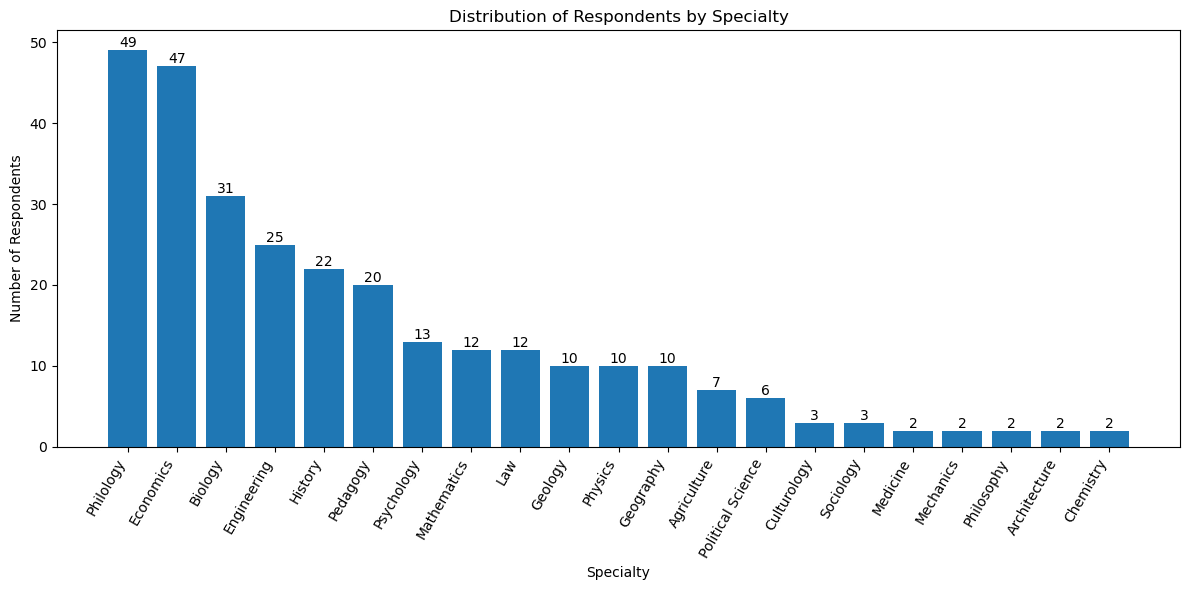

In [22]:
from collections import Counter
import matplotlib.pyplot as plt

# --- Raw data ---
data = """
Philology
Philology
Philology
Agriculture
Pedagogy
Philology
Philology
Philology
Geology
Engineering
Philology
Biology
Culturology
Philology
Philology
Philology
Philology
Biology
Economy
Agriculture
Philology
Economy
Geology
Economy
Biology
Economy
Philology
Philology
History
Economy
Economy
Biology
Agriculture
Pedagogy
Philology
Philology
Economy
Politology
Economy
Biology
Philology
Geology
Sociology
Physics
Engineering
Mathematics
Geology
Economy
Medicine
Agriculture
Physics
Philology
Biology
Biology
Geology
Physics
Mathematics
Biology
Physics
Philology
Economy
Engineering
Economy
Pedagogy
Geology
Philology
Economy
Mathematics
Economy
Philology
Engineering
Economy
Mechanics
Mathematics
Engineering
Biology
Engineering
Agriculture
History
History
Philology
Engineering
Philology
Economy
Engineering
Politology
Philology
Economy
Philology
Engineering
Agriculture
Agriculture
Engineering
Mathematics
Psychology
Philology
Economy
Economy
Engineering
Culturology
Engineering
Economy
Mathematics
Economy
Economy
Philology
Geography
Psychology
Mathematics
Physics
Psychology
Geography
Philosophy
Pedagogy
Biology
Geology
Philology
Pedagogy
Economy
History
Economy
Law
History
Psychology
Philology
History
Law
Law
Economy
Philology
Geography
Engineering
Philology
Philology
Economy
Pedagogy
Mechanics
Economy
Pedagogy
Philology
History
Engineering
Economy
Pedagogy
Economy
Economy
Psychology
Philology
Engineering
Sociology
Politology
Mathematics
Psychology
Architecture
Physics
Culturology
Pedagogy
Philology
History
Biology
Politology
Pedagogy
Law
Medicine
History
Mathematics
Philology
Philology
Economy
History
Physicology
Economy
Physics
Philology
Law
Politology
Engineering
History
Physichology
Biology
Engineering
Physics
Law
Law
Economy
Law
Engineering
Psychology
Philology
History
Engineering
History
Physchology
Physchology
Law
Biology
History
Philology
Philology
Geography
Geology
Philology
Philosophy
Engineering
History
Biology
Economy
Biology
Law
Philology
Biology
Philology
Economy
Philology
Philology
Psychology
Pedagogy
Engineering
Geography
Biology
Economy
Economy
Chemistry
Geography
Physics
Chemistry
Economy
Physics
History
Pedagogy
Engineering
Sociology
Law
Engineering
Architecture
Mathematics
Engineering
Economy
Mathematics
Biology
Philology
Philology
History
Philology
Pedagogy
Economy
Economy
Biology
Engineering
History
Geography
Economy
Economy
Geography
Economy
Pedagogy
Geology
Physchology
Biology
Law
Economy
Geography
Pedagogy
Biology
Biology
Biology
Pedagogy
History
Biology
Biology
Biology
History
Economy
Biology
Biology
History
Biology
History
Biology
Economy
Geology
Pedagogy
Biology
Mathematics
Pedagogy
Economy
Geography
Pedagogy
Pedagogy
Politology
"""

# --- Cleaning mappings ---
mapping = {
    "Physchology": "Psychology",
    "Physichology": "Psychology",
    "Physicology": "Psychology",
    "Politology": "Political Science",
    "Economy": "Economics"
}

# --- Clean data ---
cleaned = []
for line in data.split("\n"):
    item = line.strip()
    if not item:
        continue
    item = mapping.get(item, item)
    cleaned.append(item)

# --- Count frequencies ---
counts = Counter(cleaned)

# --- Sort results ---
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

labels = [x[0] for x in sorted_counts]
values = [x[1] for x in sorted_counts]

# --- Plot ---
plt.figure(figsize=(12,6))
bars = plt.bar(labels, values)

plt.xticks(rotation=60, ha='right')
plt.xlabel("Specialty")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Respondents by Specialty")

# --- Add values on top of bars ---
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.savefig("../figures/specialty_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# --- LOAD EXCEL FILE ---
df = pd.read_csv("../data/students_survey.csv")

# --- CLEAN COLUMN NAMES ---
#df.columns = ["Specialty", "EducationYear", "Form", "Employment"]

# --- CLEAN DATA ---

# Fix specialties (typos)
df["Specialty"] = df["Specialty"].replace({
    "Physchology": "Psychology",
    "Physichology": "Psychology",
    "Physicology": "Psychology",
    "Politology": "Political Science",
    "Economy": "Economics"
})

df["Specialty"] = df["Specialty"].astype(str).str.strip()

# Clean Employment
df["Employement"] = df["Employement"].astype(str).str.strip().str.lower()

emp_map = {
    "no": "Unemployed",
    "yes": "Employed",
    "teaching": "Teaching",
    "teacher": "Teaching",
    "researcher": "Research",
    "reseacher": "Research",
    "engineer": "Engineering",
    "administrative": "Administrative",
    "entrepreneurship": "Entrepreneur",
    "entrepreneur": "Entrepreneur",
    "journalist": "Media",
    "psychologist": "Psychology-related",
    "lawyer": "Legal"
}

df["Employement"] = df["Employement"].replace(emp_map)

# Fill missing values
df["Employement"] = df["Employement"].replace("", "Unknown")
df["Employement"] = df["Employement"].fillna("Unknown")

df["Form"] = df["Form"].fillna("Unknown")

# Convert year
df["Education year"] = pd.to_numeric(df["Education year"], errors="coerce")

def group_employment(x):
    x = str(x).lower()
    
    if x in ["teaching", "teacher", "research", "researcher", "publisher"]:
        return "Academic"
    
    elif x in ["engineering", "engineer", "bank", "business analytic",
               "entrepreneur", "media", "marketing specialist",
               "civil servant", "journalist"]:
        return "Industry"
    
    elif x in ["administrative"]:
        return "Administrative"
    
    elif x in ["unemployed", "no", "unknown", "yes"]:
        return "Unemployed/Other"
    
    else:
        return "Other"

df["EmploymentGroup"] = df["Employement"].apply(group_employment)
df = df[
    df["Specialty"].notna() & 
    (df["Specialty"].str.lower() != "nan")
]

# --- CROSS-TAB ANALYSIS ---



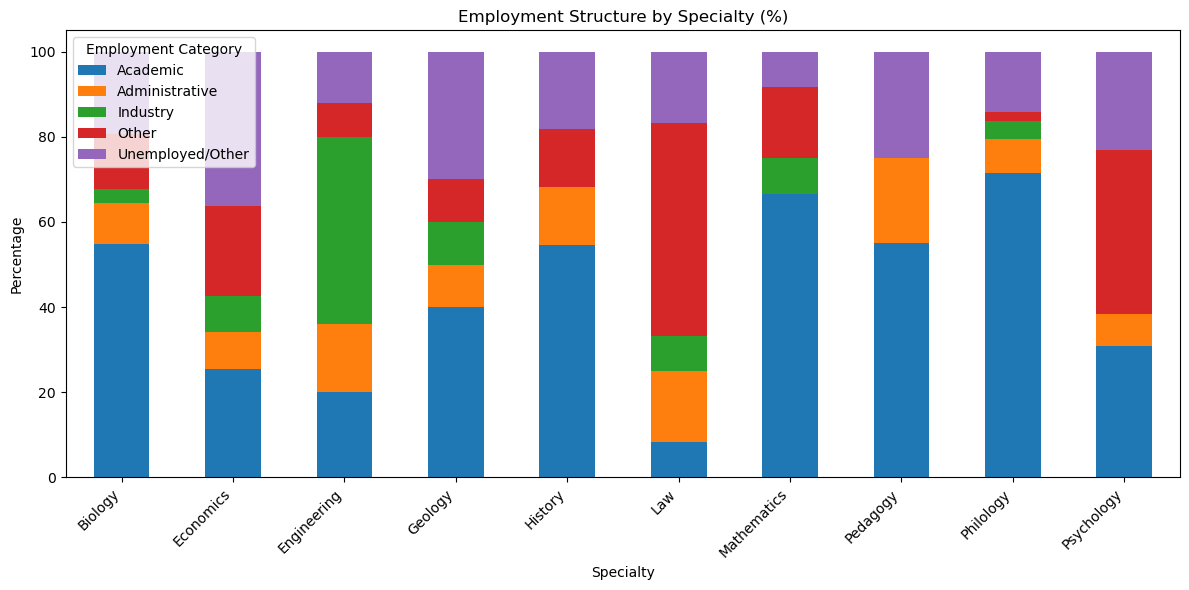

In [36]:
top_specialties = df["Specialty"].value_counts().head(10).index

ct_top = pd.crosstab(
    df[df["Specialty"].isin(top_specialties)]["Specialty"],
    df["EmploymentGroup"]
)

ct_top_pct = pd.crosstab(
    df[df["Specialty"].isin(top_specialties)]["Specialty"],
    df["EmploymentGroup"],
    normalize="index"
) * 100

ct_top_pct.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Employment Structure by Specialty (%)")
plt.xlabel("Specialty")
plt.ylabel("Percentage")

plt.xticks(rotation=45, ha='right')
plt.legend(title="Employment Category")

plt.tight_layout()
plt.savefig("../figures/specialty_vs_employment_pct.png", dpi=300)

plt.show()

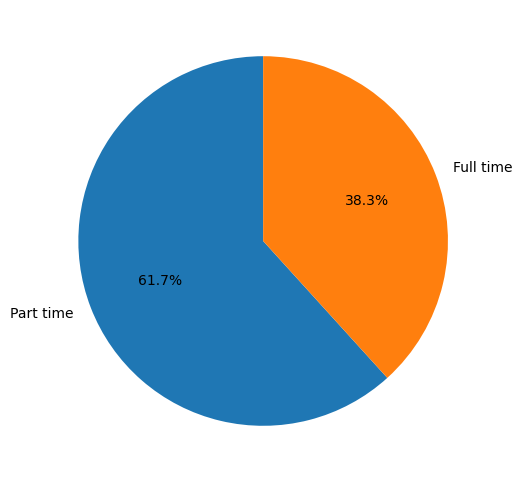

In [37]:
plt.figure(figsize=(6,6))

df["Form"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

#plt.title("Distribution by Study Form")
plt.ylabel("")

plt.savefig("../figures/form_pie.png", dpi=300)
plt.show()

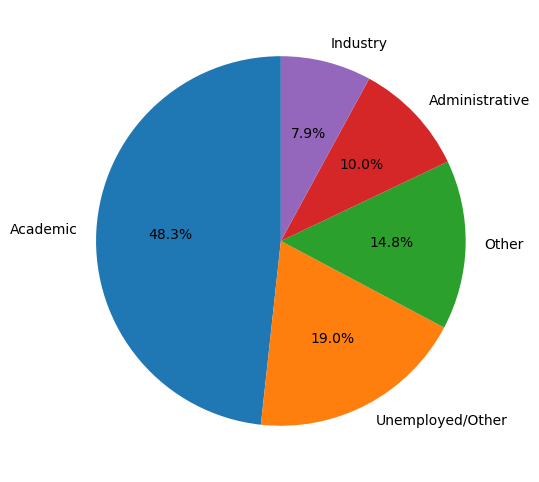

In [38]:
plt.figure(figsize=(6,6))

df["EmploymentGroup"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

#plt.title("Distribution by Study Form")
plt.ylabel("")

plt.savefig("../figures/Employ_pie.png", dpi=300)
plt.show()

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# --- LOAD DATA ---
# If Excel file:
df = pd.read_csv("../data/students_survey.csv")

# --- RENAME LONG COLUMN (for convenience) ---
df = df.rename(columns={
    "Doktorantura dövründə maliyyə vəziyyətinizdən nə dərəcədə razısınız? ": "FinancialSatisfaction"
})

# --- CLEAN DATA ---
# Remove rows where Specialty is NaN

In [39]:
df = df[df["Specialty"].notna()]

# Standardize text (very important)
df["FinancialSatisfaction"] = (
    df["FinancialSatisfaction"]
    .astype(str)
    .str.strip()
    .str.lower()
)


In [40]:
df["Specialty"] = df["Specialty"].replace({
    "Physchology": "Psychology",
    "Physichology": "Psychology",
    "Physicology": "Psychology",
    "Politology": "Political Science",
    "Economy": "Economics"
})

# --- GROUP FINANCIAL SATISFACTION ---
mapping = {
    "tam razıyam": "Satisfied",
    "qismən razıyam": "Unsure",
    "razı deyiləm": "Dissatisfied",
    "heç razı deyiləm": "Dissatisfied",
    "cavab verməkdə çətinlik çəkirəm": "Unsure"
}

df["FinGroup"] = df["FinancialSatisfaction"].map(mapping)

# Remove rows where mapping failed (optional but recommended)
df = df[df["FinGroup"].notna()]

# --- CROSSTAB ---
ct_spec_fin = pd.crosstab(df["Specialty"], df["FinGroup"])

# --- REMOVE SMALL SPECIALTIES (<5 respondents) ---
ct_spec_fin = ct_spec_fin[ct_spec_fin.sum(axis=1) >= 5]

# --- SORT BY TOTAL DESCENDING ---
ct_spec_fin = ct_spec_fin.loc[ct_spec_fin.sum(axis=1).sort_values(ascending=False).index]

print("\nCross-tab (counts):\n", ct_spec_fin)


Cross-tab (counts):
 FinGroup           Dissatisfied  Satisfied  Unsure
Specialty                                         
Philology                    25         10      14
Economics                    23          6      17
Biology                      16          6       9
Engineering                  10          2      11
History                      12          2       8
Pedagogy                      9          1       9
Psychology                    6          3       4
Law                           9          2       1
Mathematics                   4          0       8
Geography                     7          1       2
Geology                       5          0       5
Physics                       6          1       2
Agriculture                   4          1       2
Political Science             3          1       2


<Figure size 1200x600 with 0 Axes>

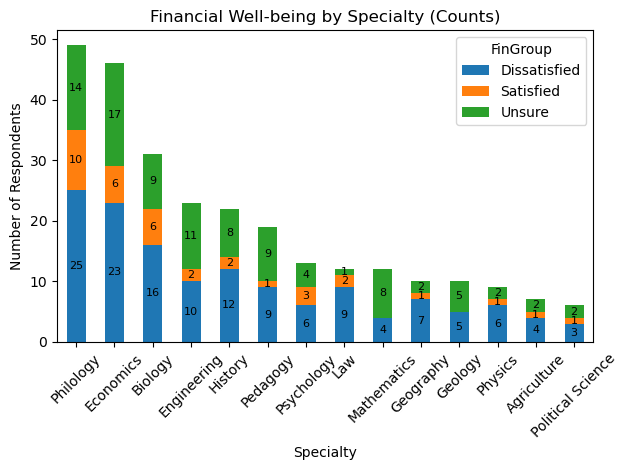

<Figure size 1200x600 with 0 Axes>

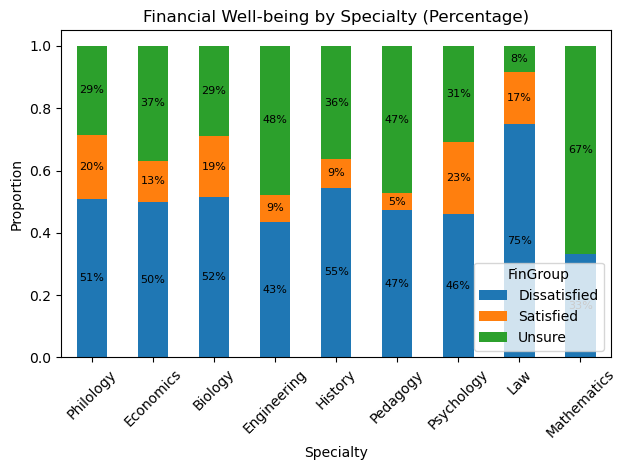

In [47]:
# Calculate total respondents per specialty
spec_counts = ct_spec_fin.sum(axis=1)

# Keep only specialties with more than 10 respondents
ct_spec_fin_filtered = ct_spec_fin[spec_counts > 5]

ct_spec_fin_filtered = ct_spec_fin_filtered.loc[
    ct_spec_fin_filtered.sum(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(12,6))

ct_spec_fin_filtered.plot(kind="bar", stacked=True)

plt.title("Financial Well-being by Specialty (Counts)")
plt.xlabel("Specialty")
plt.ylabel("Number of Respondents")

plt.xticks(rotation=45)

# Add count labels
for i, row in enumerate(ct_spec_fin_filtered.values):
    cumulative = 0
    for val in row:
        if val > 0:
            plt.text(i, cumulative + val/2, str(val),
                     ha='center', va='center', fontsize=8)
            cumulative += val

plt.tight_layout()
plt.savefig("../figures/financial_by_specialty_counts_filtered.png", dpi=300)
plt.show()

# ===============================
# 📊 VISUALIZATION 2: PERCENTAGES
# ===============================

ct_spec_fin_filtered = ct_spec_fin[spec_counts > 10]
ct_spec_fin_norm = ct_spec_fin_filtered.div(
    ct_spec_fin_filtered.sum(axis=1), axis=0
)

plt.figure(figsize=(12,6))

ct_spec_fin_norm.plot(kind="bar", stacked=True)

plt.title("Financial Well-being by Specialty (Percentage)")
plt.xlabel("Specialty")
plt.ylabel("Proportion")

plt.xticks(rotation=45)

# Add percentage labels
for i, row in enumerate(ct_spec_fin_norm.values):
    cumulative = 0
    for val in row:
        if val > 0:
            plt.text(i, cumulative + val/2, f"{val:.0%}",
                     ha='center', va='center', fontsize=8)
            cumulative += val

plt.tight_layout()
plt.savefig("../figures/financial_by_specialty_percentage.png", dpi=300)
plt.show()

In [48]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct_spec_fin_filtered)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 17.58196373326725
p-value: 0.3489376490861103
Degrees of freedom: 16


In [49]:
n = ct_spec_fin_filtered.values.sum()
phi2 = 17.58196373326725 / n
r, k = ct_spec_fin_filtered.shape

cramers_v = np.sqrt(phi2 / (min(r-1, k-1)))
print(cramers_v)

0.19679124056731992


In [51]:
# Clean column names first (important!)
df.columns = df.columns.str.strip().str.replace("\n", " ", regex=False)

# Rename for simplicity
df = df.rename(columns={
    "Doktorantura dövründə maliyyə vəziyyətinizdən nə dərəcədə razısınız?": "FinancialSatisfaction",
    "Psixoloji və sosial dəstək xidmətlərinin əlçatanlığını necə qiymətləndirirsiniz?": "SupportAccess"
})

# Crosstab
ct_fin_support = pd.crosstab(df["FinancialSatisfaction"], df["SupportAccess"])

print(ct_fin_support)

SupportAccess                    Orta  Yaxşı  Zəif  Çox zəif  Əla
FinancialSatisfaction                                            
cavab verməkdə çətinlik çəkirəm    17      4     7         3    1
heç razı deyiləm                    6      1    28        45    0
qismən razıyam                     24     19    14         8    2
razı deyiləm                       23      6    25        13    1
tam razıyam                         6     16     3         6    4


In [52]:
chi2, p, dof, expected = chi2_contingency(ct_fin_support)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 121.71089144379803
p-value: 2.5736259057308464e-18
Degrees of freedom: 16


In [53]:
n = ct_fin_support.values.sum()
phi2 = 121.71089144379803 / n
r, k = ct_fin_support.shape

cramers_v = np.sqrt(phi2 / (min(r-1, k-1)))
print(cramers_v)

0.3284809377380486


In [43]:
ct_fin_support_pct = pd.crosstab(
    df["FinancialSatisfaction"],
    df["SupportAccess"],
    normalize="index"
) * 100

print(ct_fin_support_pct.round(1))

SupportAccess                    Orta  Yaxşı  Zəif  Çox zəif   Əla
FinancialSatisfaction                                             
cavab verməkdə çətinlik çəkirəm  53.1   12.5  21.9       9.4   3.1
heç razı deyiləm                  7.5    1.2  35.0      56.2   0.0
qismən razıyam                   35.8   28.4  20.9      11.9   3.0
razı deyiləm                     33.8    8.8  36.8      19.1   1.5
tam razıyam                      17.1   45.7   8.6      17.1  11.4


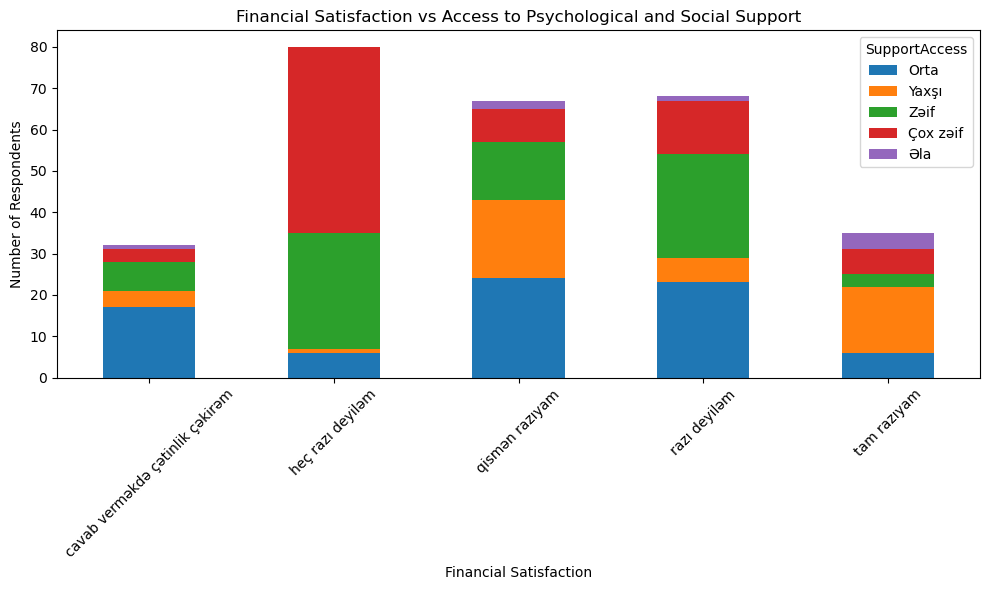

In [44]:
ct_fin_support.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Financial Satisfaction vs Access to Psychological and Social Support")
plt.xlabel("Financial Satisfaction")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../figures/wellbeing_access.png", dpi=300)
plt.show()

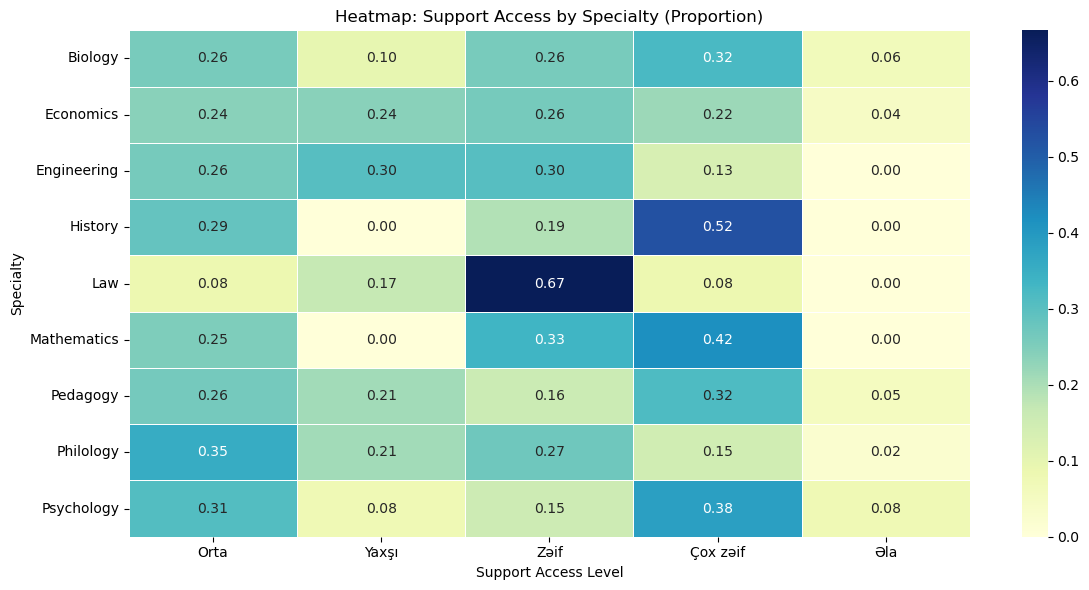

In [45]:
import seaborn as sns
# 2. CREATE CROSSTAB
# ===============================
ct = pd.crosstab(df["Specialty"], df["SupportAccess"])

# ===============================
# 3. OPTIONAL: FILTER SMALL GROUPS
# (keep specialties with >10 respondents)
# ===============================
ct = ct[ct.sum(axis=1) > 10]

# ===============================
# 4. NORMALIZE (ROW-WISE PERCENTAGES)
# ===============================
ct_norm = ct.div(ct.sum(axis=1), axis=0)

# ===============================
# 5. PLOT HEATMAP
# ===============================
plt.figure(figsize=(12, 6))

sns.heatmap(
    ct_norm,
    annot=True,          # show numbers
    fmt=".2f",           # format as decimals (0.25 = 25%)
    cmap="YlGnBu",       # color palette
    linewidths=0.5
)

plt.title("Heatmap: Support Access by Specialty (Proportion)")
plt.xlabel("Support Access Level")
plt.ylabel("Specialty")

plt.tight_layout()
plt.savefig("../figures/support_access_heatmap.png", dpi=300)
plt.show()

In [20]:
df

,Specialty,Education year,Form,Employement,Doktorantura dövründə maliyyə vəziyyətinizdən nə dərəcədə razısınız?,Psixoloji və sosial dəstək xidmətlərinin əlçatanlığını necə qiymətləndirirsiniz?,Tədqiqat resurslarına və infrastrukturuna çıxış imkanlarınızı 1-dən 10-a qədər qiymətləndirin\n,Supervisor_meeting,Quality_supervisor,Clearity_supervisor,supervising_progress,Supervisor_access,Supervisor_satisfaction,EmploymentGroup
0,Philology,1.0,Full time,Unemployed,Tam razıyam,Yaxşı,9.0,Həftədə bir dəfə,Tam razıyam,Tam razıyam,Tam razıyam,Əla,Xeyli razıyam,Unemployed/Other
1,Philology,3.0,Part time,Teaching,Razı deyiləm,Zəif,7.0,Semestrdə bir dəfədən az,Cavab verməkdə çətinlik çəkirəm,Razı deyiləm,Qismən razıyam,Zəif,Qismən razıyam,Academic
2,Philology,1.0,Part time,Teaching,Tam razıyam,Yaxşı,10.0,Ayda bir dəfə,Tam razıyam,Tam razıyam,Tam razıyam,Yaxşı,Xeyli razıyam,Academic
3,Agriculture,3.0,Full time,nan,Qismən razıyam,Orta,7.0,Ayda bir dəfə,Qismən razıyam,Qismən razıyam,Tam razıyam,Yaxşı,Xeyli razıyam,Other
4,Pedagogy,1.0,Full time,Teaching,Cavab verməkdə çətinlik çəkirəm,Orta,10.0,Həftədə bir dəfə,Tam razıyam,Tam razıyam,Tam razıyam,Əla,Xeyli razıyam,Academic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Economics,2.0,Full time,nan,Razı deyiləm,Orta,9.0,Ayda bir dəfə,Tam razıyam,Tam razıyam,Tam razıyam,Yaxşı,Xeyli razıyam,Other
296,Geography,4.0,Part time,Teaching,Qismən razıyam,Əla,8.0,Ayda bir dəfə,Tam razıyam,Tam razıyam,Tam razıyam,Əla,Xeyli razıyam,Academic
297,Pedagogy,2.0,Part time,Administrative,Razı deyiləm,Orta,8.0,Ayda bir dəfə,Qismən razıyam,Qismən razıyam,Tam razıyam,Əla,Xeyli razıyam,Administrative
298,Pedagogy,4.0,Part time,Teaching,Razı deyiləm,Orta,7.0,Həftədə bir dəfə,Tam razıyam,Tam razıyam,Tam razıyam,Əla,Xeyli razıyam,Academic


In [21]:

crosstab = pd.crosstab(df['Specialty'], df['Supervisor_satisfaction'])

print(crosstab)

Supervisor_satisfaction  Cavab verməkdə çətinlik çəkirəm  Qismən razıyam  \
Specialty                                                                  
Agriculture                                            0               1   
Architecture                                           1               0   
Biology                                                3               6   
Chemistry                                              1               1   
Culturology                                            1               0   
Economics                                              2               7   
Engineering                                            2               5   
Geography                                              0               3   
Geology                                                1               1   
History                                                0               9   
Law                                                    2               6   
Mathematics 

In [22]:
crosstab_percent = pd.crosstab(df['Specialty'], df['Supervisor_satisfaction'], 
    normalize='index'
) * 100

print(crosstab_percent)

Supervisor_satisfaction  Cavab verməkdə çətinlik çəkirəm  Qismən razıyam  \
Specialty                                                                  
Agriculture                                     0.000000       14.285714   
Architecture                                   50.000000        0.000000   
Biology                                         9.677419       19.354839   
Chemistry                                      50.000000       50.000000   
Culturology                                    33.333333        0.000000   
Economics                                       4.347826       15.217391   
Engineering                                     8.000000       20.000000   
Geography                                       0.000000       30.000000   
Geology                                        10.000000       10.000000   
History                                         0.000000       42.857143   
Law                                            16.666667       50.000000   
Mathematics 

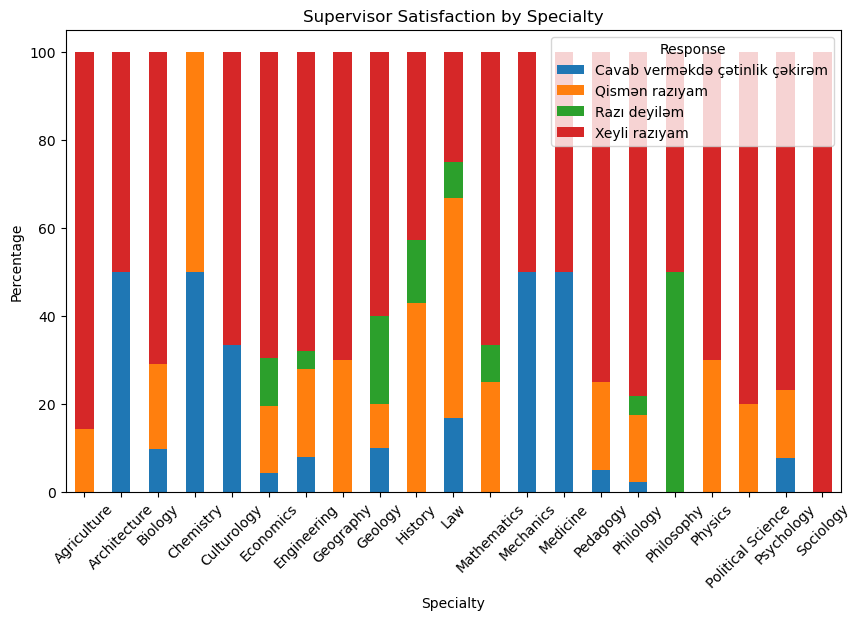

In [27]:
crosstab_percent.plot(kind='bar', stacked=True, figsize=(10,6))

plt.ylabel("Percentage")
plt.title("Supervisor Satisfaction by Specialty")
plt.legend(title="Response")
plt.xticks(rotation=45)
plt.savefig('Supervisor.jpg')
plt.show()


In [24]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(crosstab)

print("p-value:", p)

p-value: 0.01918830013025178


In [25]:
import numpy as np

n = crosstab.sum().sum()
phi2 = chi2 / n
r, k = crosstab.shape
cramers_v = np.sqrt(phi2 / (min(k-1, r-1)))

print(cramers_v)

0.31551168769622145


In [28]:
counts = df['Supervisor_meeting'].value_counts()

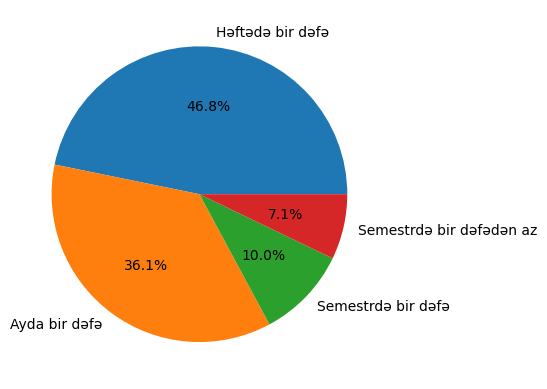

In [30]:
import matplotlib.pyplot as plt

plt.figure()

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%'
)

plt.show()

In [31]:
counts = df['Supervisor_access'].value_counts()

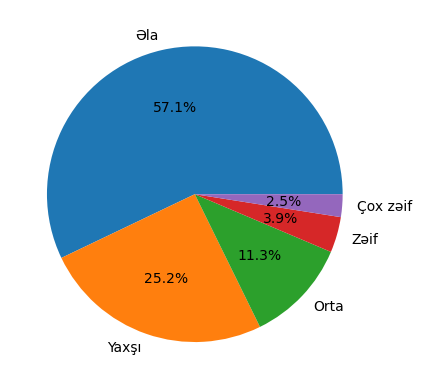

In [32]:
import matplotlib.pyplot as plt

plt.figure()

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%'
)

plt.show()